# IBM RH Análise de Atrito & Performance de Funcionários

## Análise Exploratória e Tratamentos de Dados

In [1]:
#Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick


#Arquivos auxiliares src
from src.config import DADOS_ORIGINAIS,DADOS_TRATADOS

#Configurações
pd.set_option('display.max_columns', None)




In [2]:
df= pd.read_csv(DADOS_ORIGINAIS)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# 2. Dicionário de mapeamento (Inglês -> Português)
traducao_colunas = {
    'Age': 'Idade',
    'Attrition': 'Desligamento',
    'BusinessTravel': 'ViagemDeNegocios',
    'DailyRate': 'TaxaDiaria',
    'Department': 'Departamento',
    'DistanceFromHome': 'DistanciaDeCasa',
    'Education': 'Escolaridade',
    'EducationField': 'AreaDeFormacao',
    'EmployeeCount': 'ContagemDeFuncionarios',
    'EmployeeNumber': 'NumeroDoFuncionario',
    'EnvironmentSatisfaction': 'SatisfacaoComAmbiente',
    'Gender': 'Genero',
    'HourlyRate': 'TaxaHoraria',
    'JobInvolvement': 'EnvolvimentoNoTrabalho',
    'JobLevel': 'NivelDoCargo',
    'JobRole': 'Cargo',
    'JobSatisfaction': 'SatisfacaoComOTrabalho',
    'MaritalStatus': 'EstadoCivil',
    'MonthlyIncome': 'RendaMensal',
    'MonthlyRate': 'TaxaMensal',
    'NumCompaniesWorked': 'NumeroDeEmpresasQueTrabalhou',
    'Over18': 'MaiorDe18',
    'OverTime': 'HoraExtra',
    'PercentSalaryHike': 'PercentualDeAumentoSalarial',
    'PerformanceRating': 'AvaliacaoDeDesempenho',
    'RelationshipSatisfaction': 'SatisfacaoComRelacionamentos',
    'StandardHours': 'HorasPadrao',
    'StockOptionLevel': 'NivelDeOpcoesDeAcoes',
    'TotalWorkingYears': 'TotalDeAnosTrabalhados',
    'TrainingTimesLastYear': 'TreinamentosNoAnoPassado',
    'WorkLifeBalance': 'EquilibrioVidaTrabalho',
    'YearsAtCompany': 'AnosNaEmpresa',
    'YearsInCurrentRole': 'AnosNoCargoAtual',
    'YearsSinceLastPromotion': 'AnosDesdeAUltimaPromocao',
    'YearsWithCurrManager': 'AnosComGerenteAtual'
}

# 3. Renomear as colunas no DataFrame
df.rename(columns=traducao_colunas, inplace=True)

# 4. Verificar as primeiras linhas do DataFrame para confirmar a mudança
df.head()

,Idade,Desligamento,ViagemDeNegocios,TaxaDiaria,Departamento,DistanciaDeCasa,Escolaridade,AreaDeFormacao,ContagemDeFuncionarios,NumeroDoFuncionario,SatisfacaoComAmbiente,Genero,TaxaHoraria,EnvolvimentoNoTrabalho,NivelDoCargo,Cargo,SatisfacaoComOTrabalho,EstadoCivil,RendaMensal,TaxaMensal,NumeroDeEmpresasQueTrabalhou,MaiorDe18,HoraExtra,PercentualDeAumentoSalarial,AvaliacaoDeDesempenho,SatisfacaoComRelacionamentos,HorasPadrao,NivelDeOpcoesDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,EquilibrioVidaTrabalho,AnosNaEmpresa,AnosNoCargoAtual,AnosDesdeAUltimaPromocao,AnosComGerenteAtual
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
#Tradução das colunas com texto.

# 1. Dicionário com o mapeamento dos valores de cada coluna
traducoes_valores = {
    'Desligamento': {
        'Yes': 'Sim', 
        'No': 'Não'
    },
    'ViagemDeNegocios': {
        'Non-Travel': 'Não Viaja',
        'Travel_Frequently': 'Viaja Frequentemente',
        'Travel_Rarely': 'Viaja Raramente'
    },
    'Departamento': {
        'Sales': 'Vendas',
        'Research & Development': 'Pesquisa e Desenvolvimento',
        'Human Resources': 'Recursos Humanos'
    },
    'AreaDeFormacao': {
        'Life Sciences': 'Ciências Biológicas',
        'Medical': 'Medicina',
        'Marketing': 'Marketing',
        'Technical Degree': 'Curso Técnico',
        'Human Resources': 'Recursos Humanos',
        'Other': 'Outros'
    },
    'Genero': {
        'Female': 'Feminino', 
        'Male': 'Masculino'
    },
    'Cargo': {
        'Sales Executive': 'Executivo de Vendas',
        'Research Scientist': 'Cientista de Pesquisa',
        'Laboratory Technician': 'Técnico de Laboratório',
        'Manufacturing Director': 'Diretor de Manufatura',
        'Healthcare Representative': 'Representante de Saúde',
        'Manager': 'Gerente',
        'Sales Representative': 'Representante de Vendas',
        'Research Director': 'Diretor de Pesquisa',
        'Human Resources': 'Recursos Humanos'
    },
    'EstadoCivil': {
        'Single': 'Solteiro(a)',
        'Married': 'Casado(a)',
        'Divorced': 'Divorciado(a)'
    },
    'MaiorDe18': {
        'Y': 'Sim'  # Trocando 'Y' por 'Sim' para manter o padrão
    },
    'HoraExtra': {
        'Yes': 'Sim', 
        'No': 'Não'
    }
}

# 2. Aplicar a substituição diretamente no DataFrame
df.replace(traducoes_valores, inplace=True)

# 3. Verificar o resultado em algumas colunas específicas
df.head()

,Idade,Desligamento,ViagemDeNegocios,TaxaDiaria,Departamento,DistanciaDeCasa,Escolaridade,AreaDeFormacao,ContagemDeFuncionarios,NumeroDoFuncionario,SatisfacaoComAmbiente,Genero,TaxaHoraria,EnvolvimentoNoTrabalho,NivelDoCargo,Cargo,SatisfacaoComOTrabalho,EstadoCivil,RendaMensal,TaxaMensal,NumeroDeEmpresasQueTrabalhou,MaiorDe18,HoraExtra,PercentualDeAumentoSalarial,AvaliacaoDeDesempenho,SatisfacaoComRelacionamentos,HorasPadrao,NivelDeOpcoesDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,EquilibrioVidaTrabalho,AnosNaEmpresa,AnosNoCargoAtual,AnosDesdeAUltimaPromocao,AnosComGerenteAtual
0,41,Sim,Viaja Raramente,1102,Vendas,1,2,Ciências Biológicas,1,1,2,Feminino,94,3,2,Executivo de Vendas,4,Solteiro(a),5993,19479,8,Sim,Sim,11,3,1,80,0,8,0,1,6,4,0,5
1,49,Não,Viaja Frequentemente,279,Pesquisa e Desenvolvimento,8,1,Ciências Biológicas,1,2,3,Masculino,61,2,2,Cientista de Pesquisa,2,Casado(a),5130,24907,1,Sim,Não,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Sim,Viaja Raramente,1373,Pesquisa e Desenvolvimento,2,2,Outros,1,4,4,Masculino,92,2,1,Técnico de Laboratório,3,Solteiro(a),2090,2396,6,Sim,Sim,15,3,2,80,0,7,3,3,0,0,0,0
3,33,Não,Viaja Frequentemente,1392,Pesquisa e Desenvolvimento,3,4,Ciências Biológicas,1,5,4,Feminino,56,3,1,Cientista de Pesquisa,3,Casado(a),2909,23159,1,Sim,Sim,11,3,3,80,0,8,3,3,8,7,3,0
4,27,Não,Viaja Raramente,591,Pesquisa e Desenvolvimento,2,1,Medicina,1,7,1,Masculino,40,3,1,Técnico de Laboratório,2,Casado(a),3468,16632,9,Sim,Não,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Idade                         1470 non-null   int64
 1   Desligamento                  1470 non-null   str  
 2   ViagemDeNegocios              1470 non-null   str  
 3   TaxaDiaria                    1470 non-null   int64
 4   Departamento                  1470 non-null   str  
 5   DistanciaDeCasa               1470 non-null   int64
 6   Escolaridade                  1470 non-null   int64
 7   AreaDeFormacao                1470 non-null   str  
 8   ContagemDeFuncionarios        1470 non-null   int64
 9   NumeroDoFuncionario           1470 non-null   int64
 10  SatisfacaoComAmbiente         1470 non-null   int64
 11  Genero                        1470 non-null   str  
 12  TaxaHoraria                   1470 non-null   int64
 13  EnvolvimentoNoTrabalho        1470 non-null 

In [6]:
df.describe()

,Idade,TaxaDiaria,DistanciaDeCasa,Escolaridade,ContagemDeFuncionarios,NumeroDoFuncionario,SatisfacaoComAmbiente,TaxaHoraria,EnvolvimentoNoTrabalho,NivelDoCargo,SatisfacaoComOTrabalho,RendaMensal,TaxaMensal,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,AvaliacaoDeDesempenho,SatisfacaoComRelacionamentos,HorasPadrao,NivelDeOpcoesDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,EquilibrioVidaTrabalho,AnosNaEmpresa,AnosNoCargoAtual,AnosDesdeAUltimaPromocao,AnosComGerenteAtual
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.describe(exclude='number')

,Desligamento,ViagemDeNegocios,Departamento,AreaDeFormacao,Genero,Cargo,EstadoCivil,MaiorDe18,HoraExtra
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,Não,Viaja Raramente,Pesquisa e Desenvolvimento,Ciências Biológicas,Masculino,Executivo de Vendas,Casado(a),Sim,Não
freq,1233,1043,961,606,882,326,673,1470,1054


In [8]:
df.nunique()

Idade                             43
Desligamento                       2
ViagemDeNegocios                   3
TaxaDiaria                       886
Departamento                       3
DistanciaDeCasa                   29
Escolaridade                       5
AreaDeFormacao                     6
ContagemDeFuncionarios             1
NumeroDoFuncionario             1470
SatisfacaoComAmbiente              4
Genero                             2
TaxaHoraria                       71
EnvolvimentoNoTrabalho             4
NivelDoCargo                       5
Cargo                              9
SatisfacaoComOTrabalho             4
EstadoCivil                        3
RendaMensal                     1349
TaxaMensal                      1427
NumeroDeEmpresasQueTrabalhou      10
MaiorDe18                          1
HoraExtra                          2
PercentualDeAumentoSalarial       15
AvaliacaoDeDesempenho              2
SatisfacaoComRelacionamentos       4
HorasPadrao                        1
N

Colunas com valores unicos:
- `ContagemDeFuncionarios`: valor unico
- `NumeroDoFuncionario`: valores unicos
- `MaiorDe18`: valor unico
- `HorasPadrao`: valor unico

In [9]:
#Drop das colunas irrelevantes
colunas_para_dropar = ['ContagemDeFuncionarios', 'HorasPadrao', 'NumeroDoFuncionario','MaiorDe18']
df.drop(columns=colunas_para_dropar, inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Idade                         1470 non-null   int64
 1   Desligamento                  1470 non-null   str  
 2   ViagemDeNegocios              1470 non-null   str  
 3   TaxaDiaria                    1470 non-null   int64
 4   Departamento                  1470 non-null   str  
 5   DistanciaDeCasa               1470 non-null   int64
 6   Escolaridade                  1470 non-null   int64
 7   AreaDeFormacao                1470 non-null   str  
 8   SatisfacaoComAmbiente         1470 non-null   int64
 9   Genero                        1470 non-null   str  
 10  TaxaHoraria                   1470 non-null   int64
 11  EnvolvimentoNoTrabalho        1470 non-null   int64
 12  NivelDoCargo                  1470 non-null   int64
 13  Cargo                         1470 non-null 

In [11]:
# Reordena as colunas do DataFrame em ordem alfabética
df = df.reindex(sorted(df.columns), axis=1)

# Visualiza o resultado
df.head()

,AnosComGerenteAtual,AnosDesdeAUltimaPromocao,AnosNaEmpresa,AnosNoCargoAtual,AreaDeFormacao,AvaliacaoDeDesempenho,Cargo,Departamento,Desligamento,DistanciaDeCasa,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,EstadoCivil,Genero,HoraExtra,Idade,NivelDeOpcoesDeAcoes,NivelDoCargo,NumeroDeEmpresasQueTrabalhou,PercentualDeAumentoSalarial,RendaMensal,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,TaxaDiaria,TaxaHoraria,TaxaMensal,TotalDeAnosTrabalhados,TreinamentosNoAnoPassado,ViagemDeNegocios
0,5,0,6,4,Ciências Biológicas,3,Executivo de Vendas,Vendas,Sim,1,3,1,2,Solteiro(a),Feminino,Sim,41,0,2,8,11,5993,2,4,1,1102,94,19479,8,0,Viaja Raramente
1,7,1,10,7,Ciências Biológicas,4,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,8,2,3,1,Casado(a),Masculino,Não,49,1,2,1,23,5130,3,2,4,279,61,24907,10,3,Viaja Frequentemente
2,0,0,0,0,Outros,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Sim,2,2,3,2,Solteiro(a),Masculino,Sim,37,0,1,6,15,2090,4,3,2,1373,92,2396,7,3,Viaja Raramente
3,0,3,8,7,Ciências Biológicas,3,Cientista de Pesquisa,Pesquisa e Desenvolvimento,Não,3,3,3,4,Casado(a),Feminino,Sim,33,0,1,1,11,2909,4,3,3,1392,56,23159,8,3,Viaja Frequentemente
4,2,2,2,2,Medicina,3,Técnico de Laboratório,Pesquisa e Desenvolvimento,Não,2,3,3,1,Casado(a),Masculino,Não,27,1,1,9,12,3468,1,2,4,591,40,16632,6,3,Viaja Raramente


In [12]:
#linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [13]:
#linhas vazias
df.isnull().sum()

AnosComGerenteAtual             0
AnosDesdeAUltimaPromocao        0
AnosNaEmpresa                   0
AnosNoCargoAtual                0
AreaDeFormacao                  0
AvaliacaoDeDesempenho           0
Cargo                           0
Departamento                    0
Desligamento                    0
DistanciaDeCasa                 0
EnvolvimentoNoTrabalho          0
EquilibrioVidaTrabalho          0
Escolaridade                    0
EstadoCivil                     0
Genero                          0
HoraExtra                       0
Idade                           0
NivelDeOpcoesDeAcoes            0
NivelDoCargo                    0
NumeroDeEmpresasQueTrabalhou    0
PercentualDeAumentoSalarial     0
RendaMensal                     0
SatisfacaoComAmbiente           0
SatisfacaoComOTrabalho          0
SatisfacaoComRelacionamentos    0
TaxaDiaria                      0
TaxaHoraria                     0
TaxaMensal                      0
TotalDeAnosTrabalhados          0
TreinamentosNo

In [14]:
coluna_alvo = ['Desligamento']
print(f"Coluna alvo: {coluna_alvo}")

colunas_categoricas_ordenadas = [
    'AvaliacaoDeDesempenho', 
    'EnvolvimentoNoTrabalho',
    'EquilibrioVidaTrabalho',
    'Escolaridade',
    'NivelDoCargo',
    'SatisfacaoComAmbiente',
    'SatisfacaoComOTrabalho',
    'SatisfacaoComRelacionamentos', 
    'ViagemDeNegocios',
    'NivelDeOpcoesDeAcoes'
    ]
print(f"Colunas categóricas ordenadas: {colunas_categoricas_ordenadas}")

colunas_categoricas = df.select_dtypes(include='str').columns.tolist()
colunas_categoricas.remove(coluna_alvo[0])
#remover ordenandas
colunas_categoricas = [col for col in colunas_categoricas if col not in colunas_categoricas_ordenadas]
print(f"Colunas categóricas: {colunas_categoricas}")

colunas_numericas = [col for col in df.columns if col not in (colunas_categoricas_ordenadas+colunas_categoricas+coluna_alvo)]
print(f"Colunas numéricas: {colunas_numericas}")


Coluna alvo: ['Desligamento']
Colunas categóricas ordenadas: ['AvaliacaoDeDesempenho', 'EnvolvimentoNoTrabalho', 'EquilibrioVidaTrabalho', 'Escolaridade', 'NivelDoCargo', 'SatisfacaoComAmbiente', 'SatisfacaoComOTrabalho', 'SatisfacaoComRelacionamentos', 'ViagemDeNegocios', 'NivelDeOpcoesDeAcoes']
Colunas categóricas: ['AreaDeFormacao', 'Cargo', 'Departamento', 'EstadoCivil', 'Genero', 'HoraExtra']
Colunas numéricas: ['AnosComGerenteAtual', 'AnosDesdeAUltimaPromocao', 'AnosNaEmpresa', 'AnosNoCargoAtual', 'DistanciaDeCasa', 'Idade', 'NumeroDeEmpresasQueTrabalhou', 'PercentualDeAumentoSalarial', 'RendaMensal', 'TaxaDiaria', 'TaxaHoraria', 'TaxaMensal', 'TotalDeAnosTrabalhados', 'TreinamentosNoAnoPassado']


Text(0.5, 1.0, 'Distribuição da Coluna Alvo (Desligamento)')

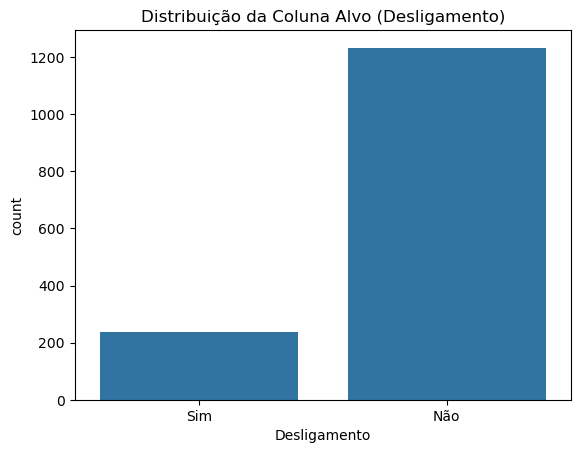

In [15]:
sns.countplot(data=df, x=coluna_alvo[0])
plt.title('Distribuição da Coluna Alvo (Desligamento)')

In [16]:
df.Desligamento.value_counts()

Desligamento
Não    1233
Sim     237
Name: count, dtype: int64

Temos um desbalançamento da coluna alvo.


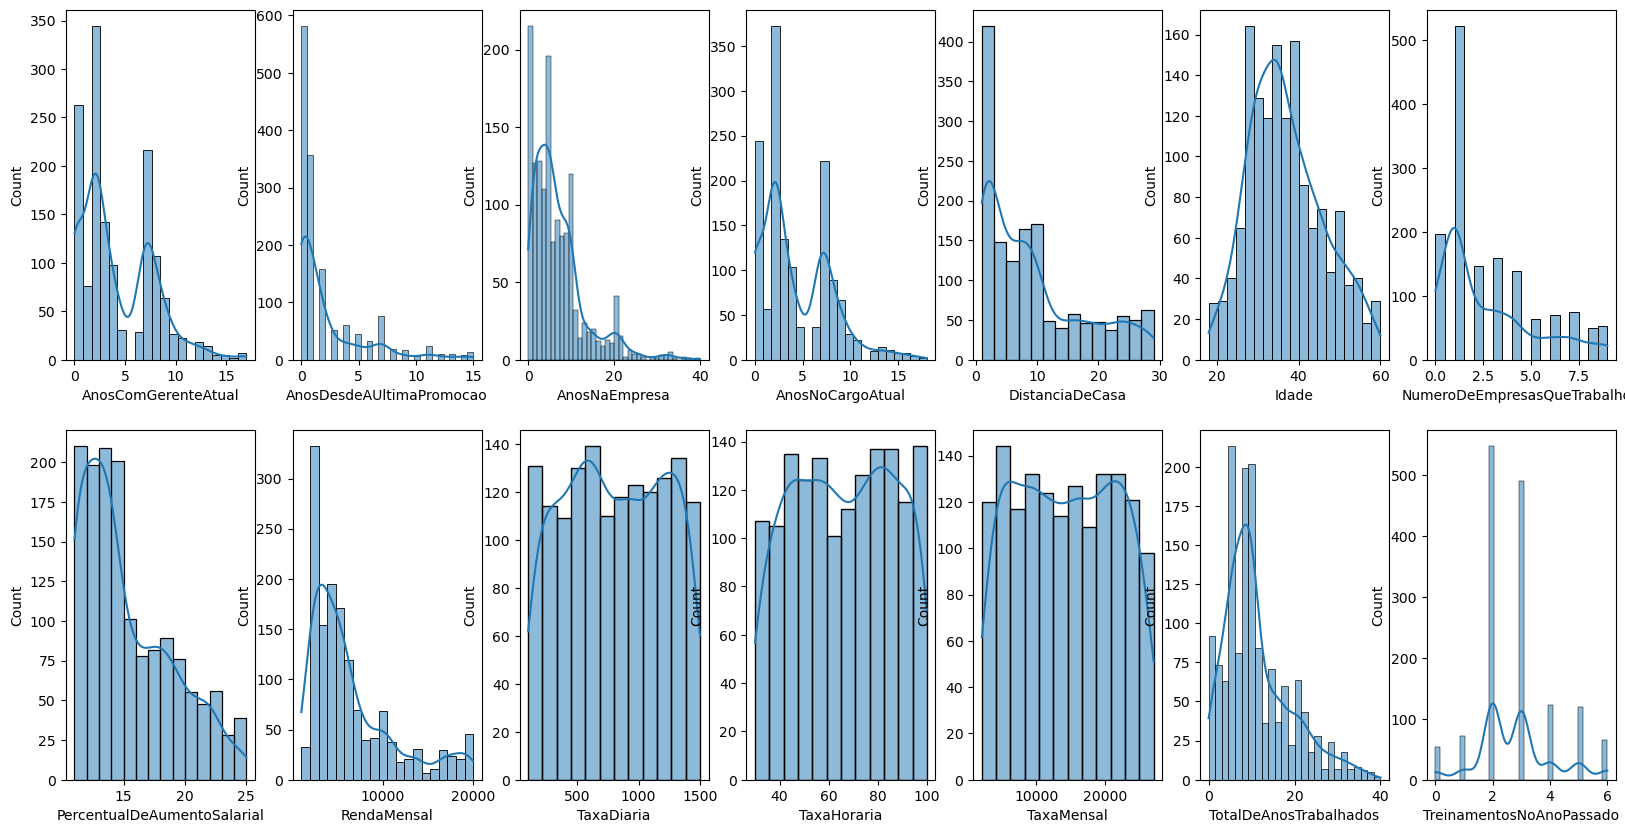

In [17]:
#histograma de colunas numericas

fig, axs = plt.subplots(2,7, figsize=(20,10))

for ax,col in zip(axs.flatten(), colunas_numericas):
    sns.histplot(data=df, x=col, kde=True, ax=ax)

plt.tight_layout
plt.show()


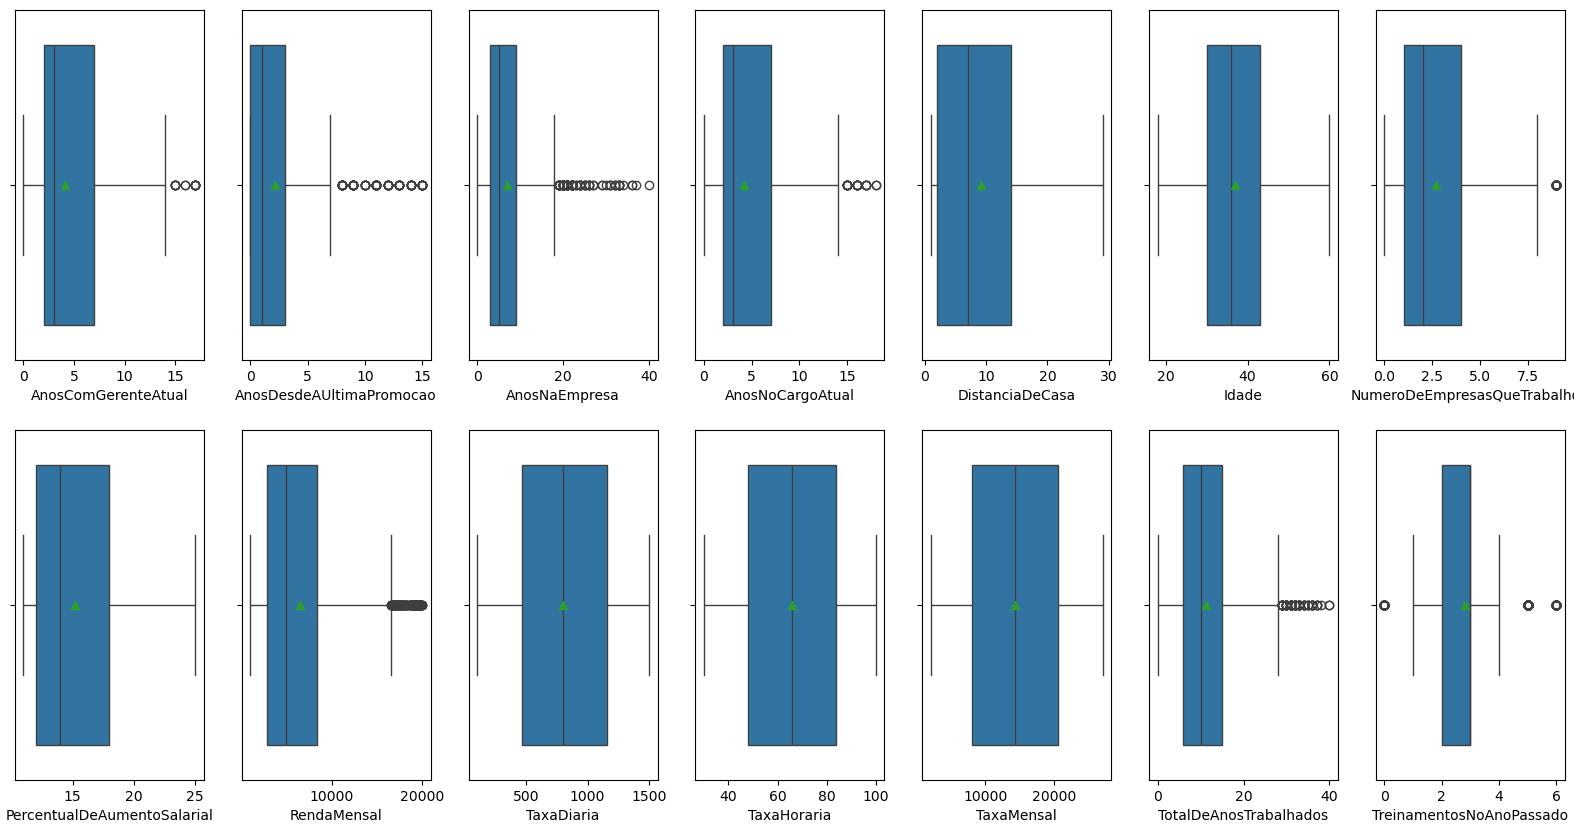

In [18]:
#boxplot de colunas numericas

fig, axs = plt.subplots(2,7, figsize=(20,10))

for ax,col in zip(axs.flatten(), colunas_numericas):
    sns.boxplot(data=df, x=col, ax=ax, showmeans=True)

plt.tight_layout
plt.show()

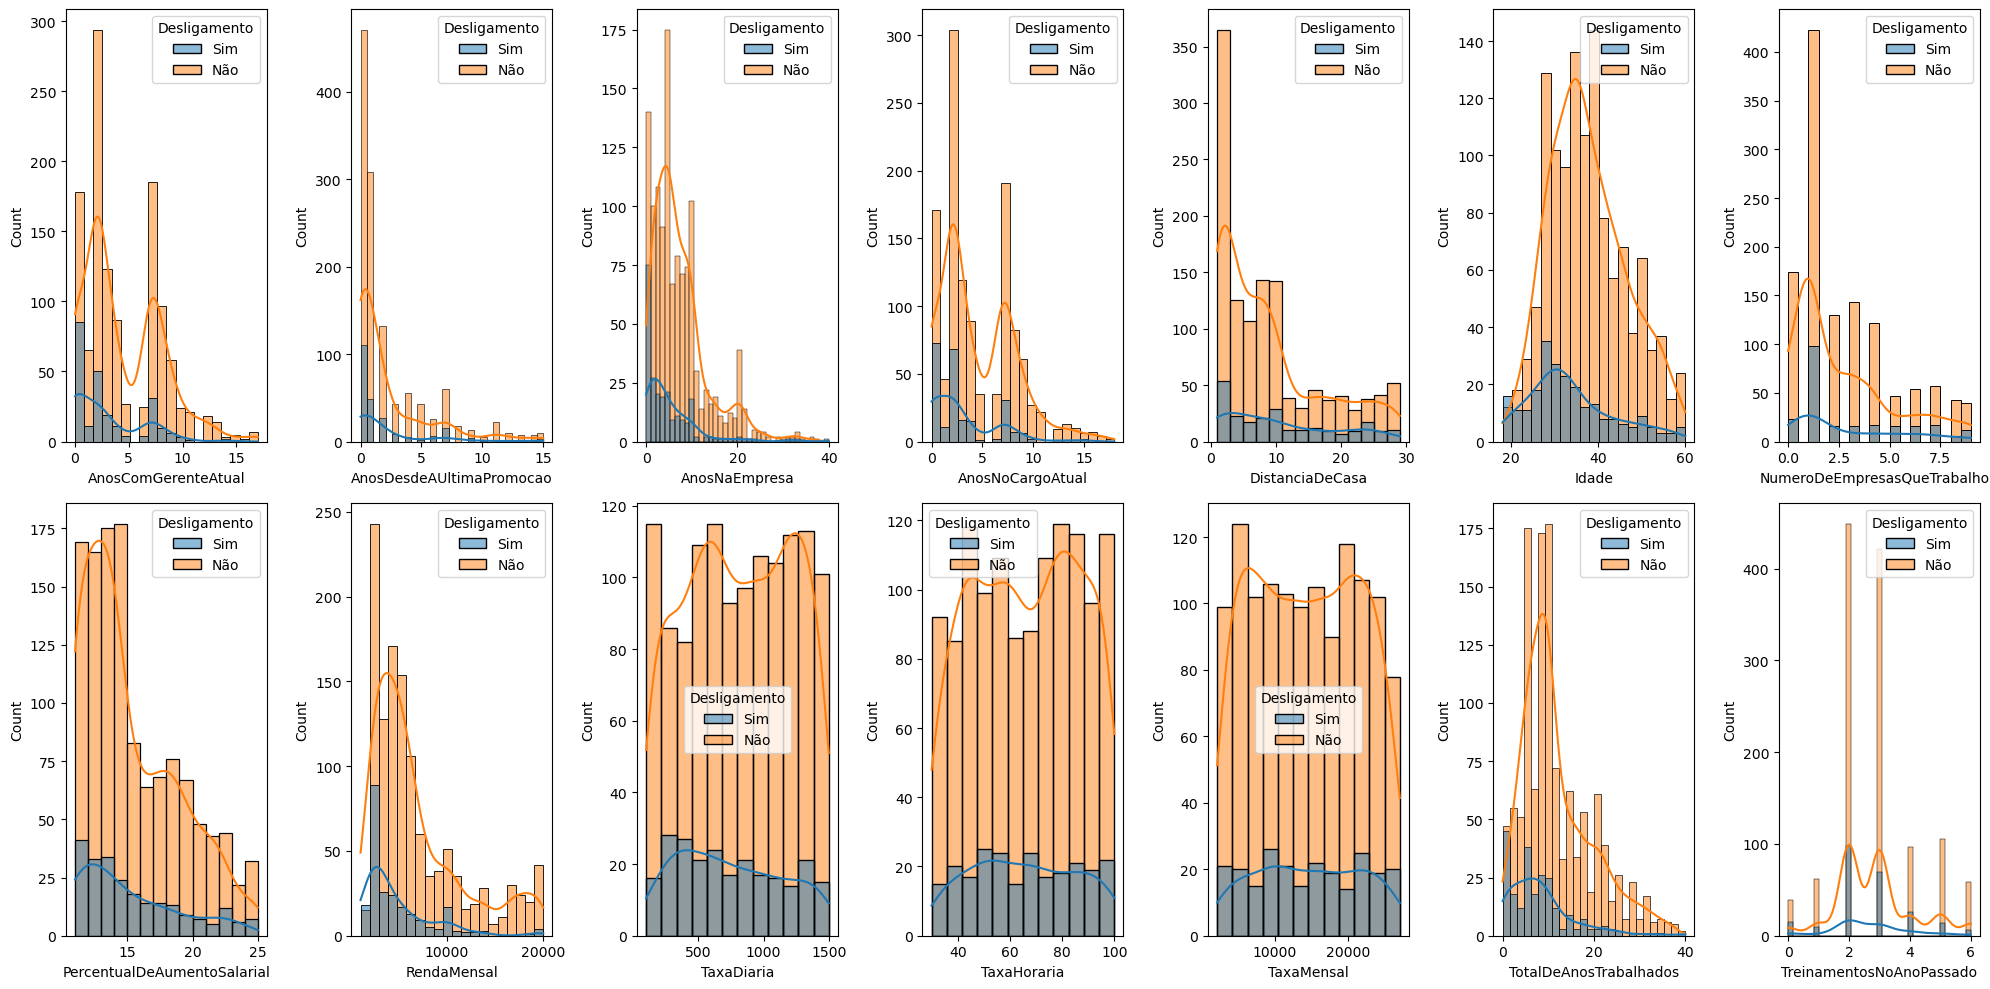

In [19]:
#histograma de colunas numericas por desligamento

fig, axs = plt.subplots(2,7, figsize=(20,10))

for ax,col in zip(axs.flatten(), colunas_numericas):
    sns.histplot(data=df, x=col,hue=coluna_alvo[0], kde=True, ax=ax)

plt.tight_layout()
plt.show()

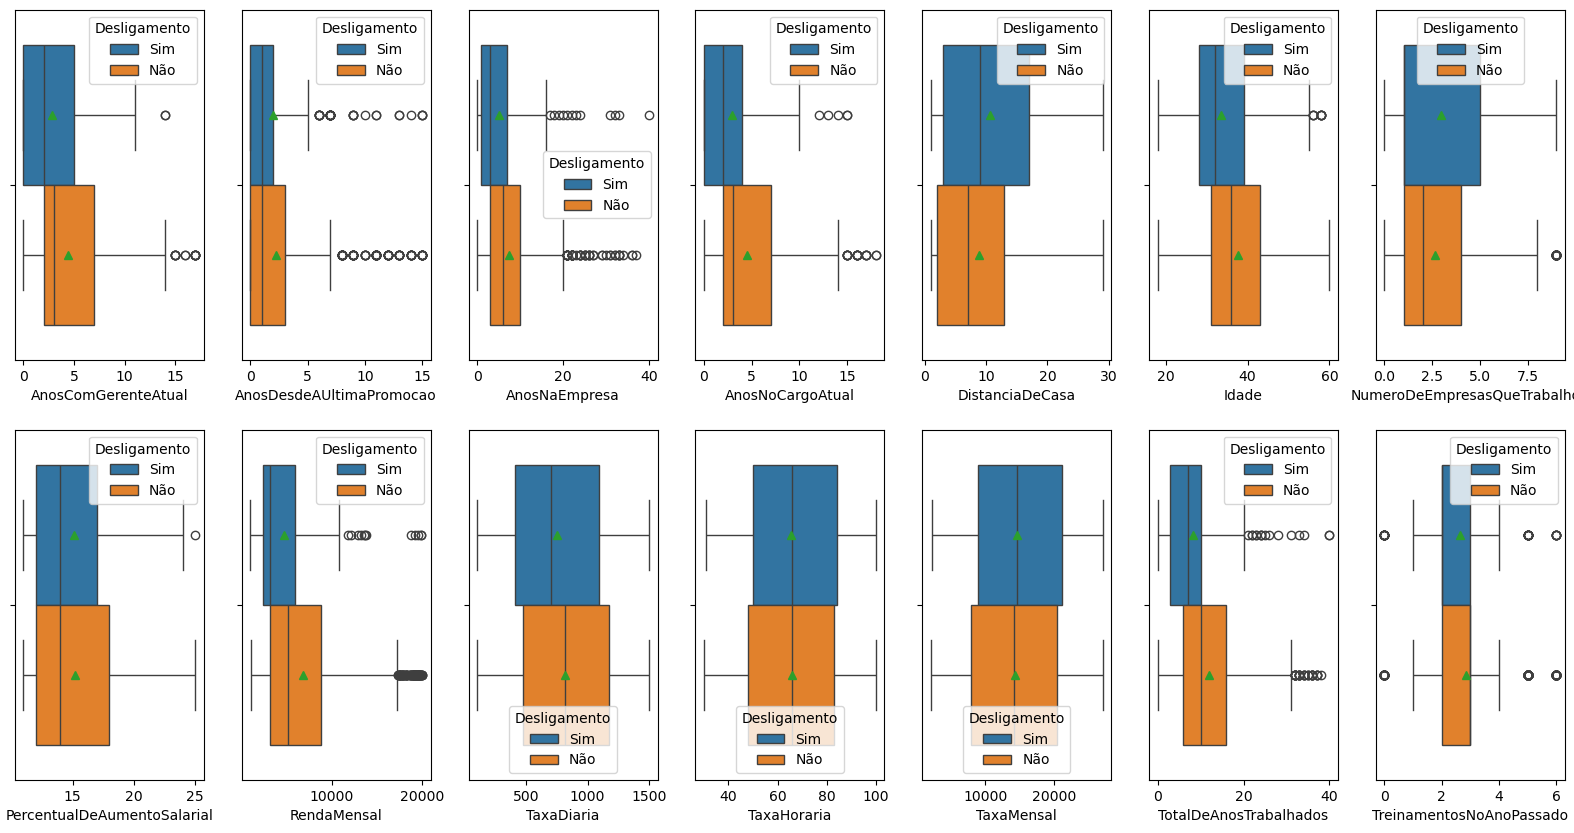

In [20]:
#boxplot de colunas numericas

fig, axs = plt.subplots(2,7, figsize=(20,10))

for ax,col in zip(axs.flatten(), colunas_numericas):
    sns.boxplot(data=df, x=col, ax=ax,hue=coluna_alvo[0], showmeans=True)

plt.tight_layout
plt.show()

In [21]:
df[colunas_categoricas_ordenadas].head()

,AvaliacaoDeDesempenho,EnvolvimentoNoTrabalho,EquilibrioVidaTrabalho,Escolaridade,NivelDoCargo,SatisfacaoComAmbiente,SatisfacaoComOTrabalho,SatisfacaoComRelacionamentos,ViagemDeNegocios,NivelDeOpcoesDeAcoes
0,3,3,1,2,2,2,4,1,Viaja Raramente,0
1,4,2,3,1,2,3,2,4,Viaja Frequentemente,1
2,3,2,3,2,1,4,3,2,Viaja Raramente,0
3,3,3,3,4,1,4,3,3,Viaja Frequentemente,0
4,3,3,3,1,1,1,2,4,Viaja Raramente,1


In [22]:
df.ViagemDeNegocios.value_counts()

ViagemDeNegocios
Viaja Raramente         1043
Viaja Frequentemente     277
Não Viaja                150
Name: count, dtype: int64

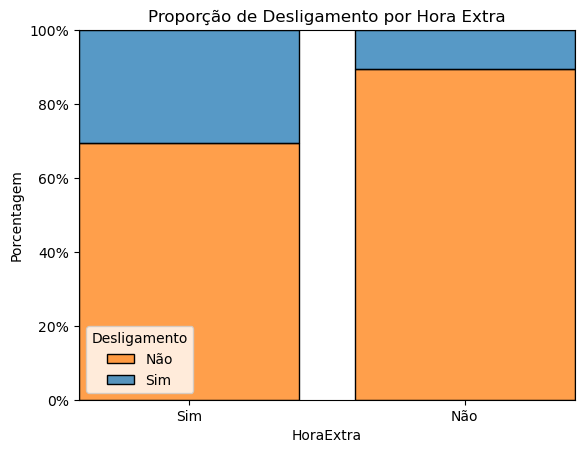

In [23]:
#Hora Extra
ax = sns.histplot(data=df, x='HoraExtra', hue=coluna_alvo[0], multiple='fill', shrink=0.8)

plt.title('Proporção de Desligamento por Hora Extra')
plt.ylabel('Porcentagem')

# Formata o eixo Y para exibir porcentagens
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(title='Desligamento', loc='lower left', labels=['Não', 'Sim'])

plt.show()

In [24]:
ordem_correta = ['Não Viaja', 'Viaja Raramente', 'Viaja Frequentemente']
df['ViagemDeNegocios'] = pd.Categorical(df['ViagemDeNegocios'], categories=ordem_correta, ordered=True)

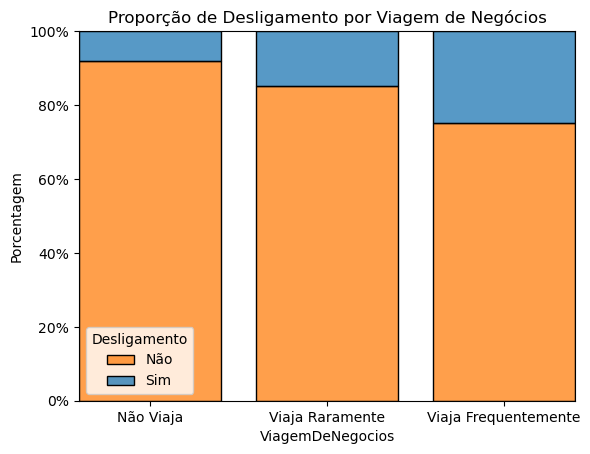

In [25]:
#Viagem de negócios

ax = sns.histplot(data=df, x='ViagemDeNegocios', hue=coluna_alvo[0], multiple='fill', shrink=0.8)

plt.title('Proporção de Desligamento por Viagem de Negócios')
plt.ylabel('Porcentagem')

# Formata o eixo Y para exibir porcentagens
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(title='Desligamento', loc='lower left', labels=['Não', 'Sim'])

plt.show()

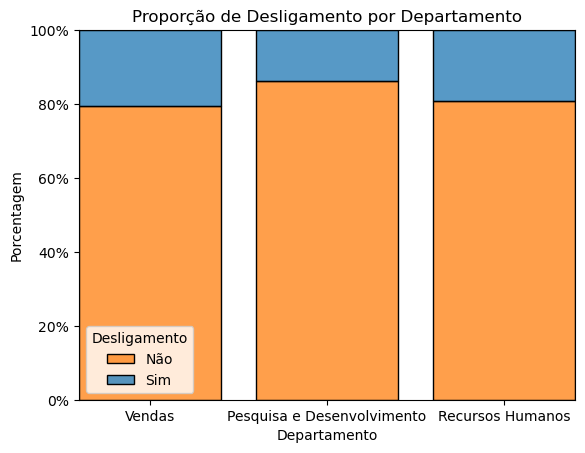

In [26]:
#Departamento
ax = sns.histplot(data=df, x='Departamento', hue=coluna_alvo[0], multiple='fill', shrink=0.8)

plt.title('Proporção de Desligamento por Departamento')
plt.ylabel('Porcentagem')

# Formata o eixo Y para exibir porcentagens
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(title='Desligamento', loc='lower left', labels=['Não', 'Sim'])

plt.show()

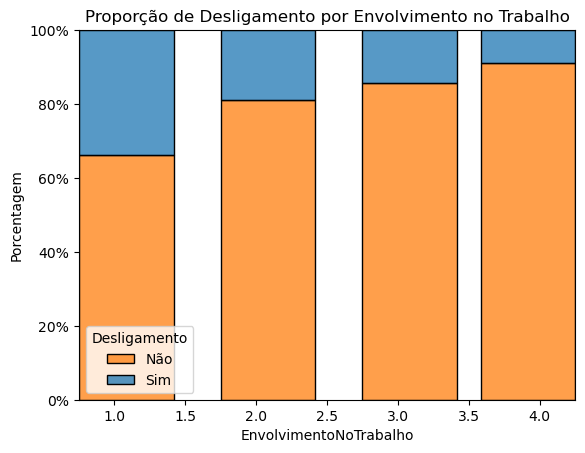

In [27]:
#Envolvimento no trabalho
ax = sns.histplot(data=df, x='EnvolvimentoNoTrabalho', hue=coluna_alvo[0], multiple='fill', shrink=4)

plt.title('Proporção de Desligamento por Envolvimento no Trabalho')
plt.ylabel('Porcentagem')

# Formata o eixo Y para exibir porcentagens
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(title='Desligamento', loc='lower left', labels=['Não', 'Sim'])

plt.show()

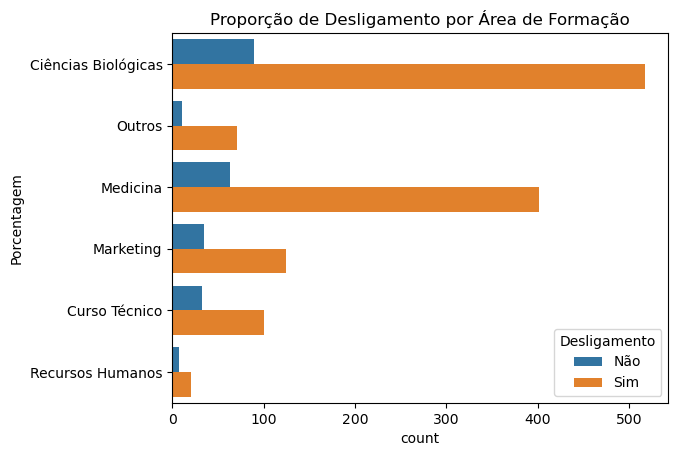

In [28]:
#Área formação
ax = sns.countplot(data=df, y='AreaDeFormacao', hue=coluna_alvo[0] )

plt.title('Proporção de Desligamento por Área de Formação')
plt.ylabel('Porcentagem')



ax.legend(title='Desligamento', loc='lower right', labels=['Não', 'Sim'])

plt.show()

In [29]:
#Cargo

df['Cargo'].value_counts()

Cargo
Executivo de Vendas        326
Cientista de Pesquisa      292
Técnico de Laboratório     259
Diretor de Manufatura      145
Representante de Saúde     131
Gerente                    102
Representante de Vendas     83
Diretor de Pesquisa         80
Recursos Humanos            52
Name: count, dtype: int64

In [30]:
pd.crosstab(df['Cargo'], df['NivelDoCargo'])

NivelDoCargo,1,2,3,4,5
Cargo,,,,,
Cientista de Pesquisa,234,57,1,0,0
Diretor de Manufatura,0,90,45,10,0
Diretor de Pesquisa,0,0,28,26,26
Executivo de Vendas,0,233,79,14,0
Gerente,0,0,12,47,43
Recursos Humanos,33,13,6,0,0
Representante de Saúde,0,78,44,9,0
Representante de Vendas,76,7,0,0,0
Técnico de Laboratório,200,56,3,0,0


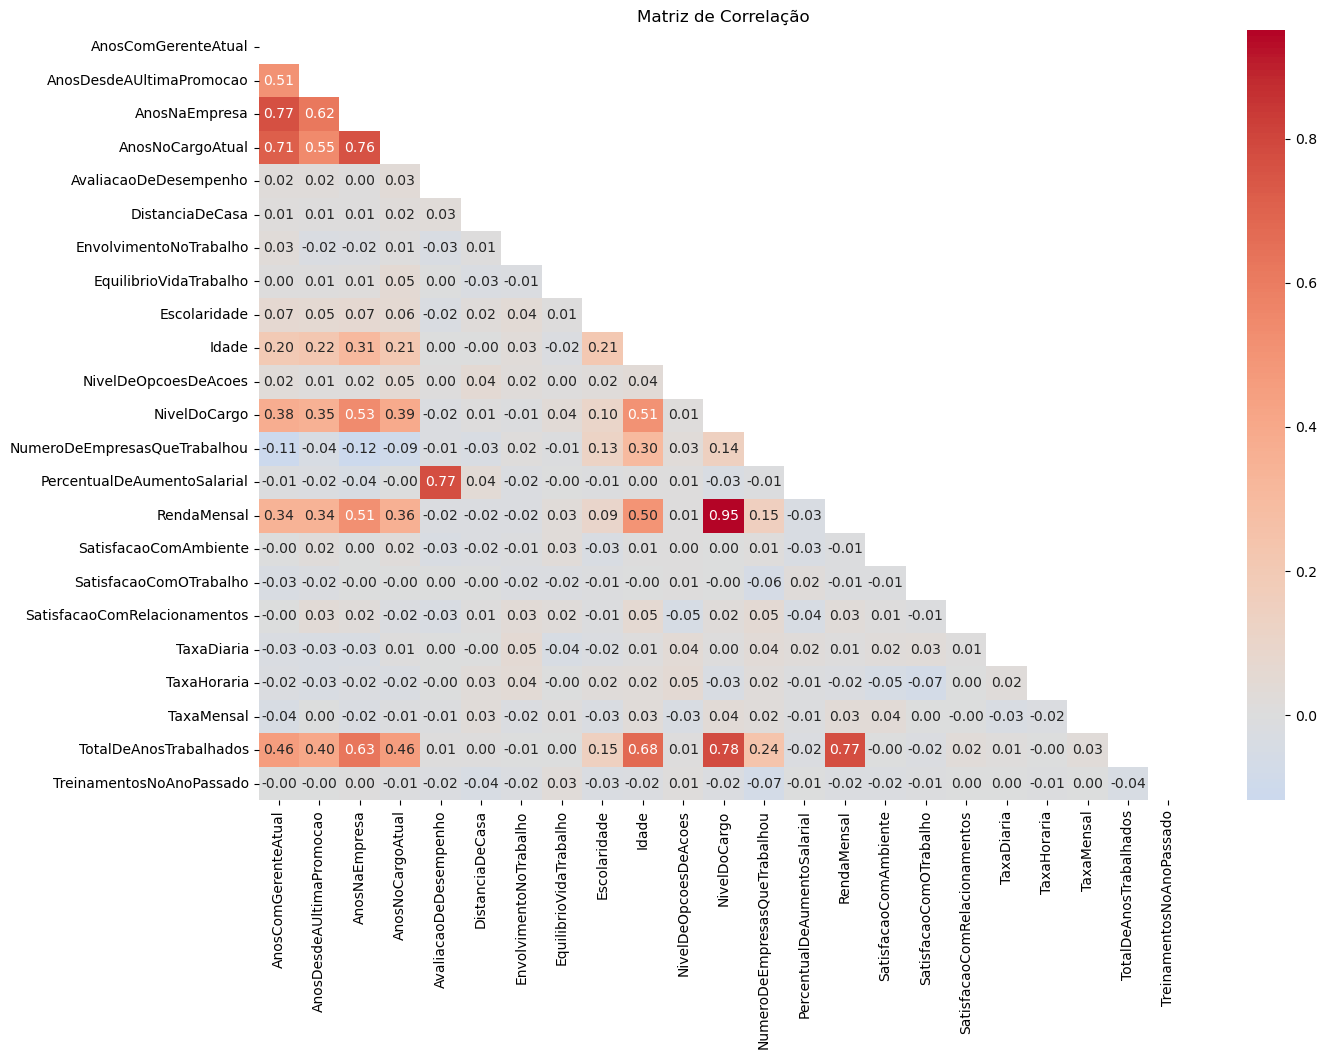

In [31]:
#analise de correlação

corr = df.select_dtypes(include=[np.number]).corr()

triu = np.triu(corr)

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, mask=triu, fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   AnosComGerenteAtual           1470 non-null   int64   
 1   AnosDesdeAUltimaPromocao      1470 non-null   int64   
 2   AnosNaEmpresa                 1470 non-null   int64   
 3   AnosNoCargoAtual              1470 non-null   int64   
 4   AreaDeFormacao                1470 non-null   str     
 5   AvaliacaoDeDesempenho         1470 non-null   int64   
 6   Cargo                         1470 non-null   str     
 7   Departamento                  1470 non-null   str     
 8   Desligamento                  1470 non-null   str     
 9   DistanciaDeCasa               1470 non-null   int64   
 10  EnvolvimentoNoTrabalho        1470 non-null   int64   
 11  EquilibrioVidaTrabalho        1470 non-null   int64   
 12  Escolaridade                  1470 non-null   int64   
 13 

In [33]:
colunas_valores_inteiros = [coluna for coluna in df.select_dtypes('int')]

colunas_valores_inteiros

['AnosComGerenteAtual',
 'AnosDesdeAUltimaPromocao',
 'AnosNaEmpresa',
 'AnosNoCargoAtual',
 'AvaliacaoDeDesempenho',
 'DistanciaDeCasa',
 'EnvolvimentoNoTrabalho',
 'EquilibrioVidaTrabalho',
 'Escolaridade',
 'Idade',
 'NivelDeOpcoesDeAcoes',
 'NivelDoCargo',
 'NumeroDeEmpresasQueTrabalhou',
 'PercentualDeAumentoSalarial',
 'RendaMensal',
 'SatisfacaoComAmbiente',
 'SatisfacaoComOTrabalho',
 'SatisfacaoComRelacionamentos',
 'TaxaDiaria',
 'TaxaHoraria',
 'TaxaMensal',
 'TotalDeAnosTrabalhados',
 'TreinamentosNoAnoPassado']

In [34]:
#downcast de colunas numéricas para reduzir o uso de memória
df[colunas_valores_inteiros] = df[colunas_valores_inteiros].apply(pd.to_numeric, downcast='integer')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   AnosComGerenteAtual           1470 non-null   int8    
 1   AnosDesdeAUltimaPromocao      1470 non-null   int8    
 2   AnosNaEmpresa                 1470 non-null   int8    
 3   AnosNoCargoAtual              1470 non-null   int8    
 4   AreaDeFormacao                1470 non-null   str     
 5   AvaliacaoDeDesempenho         1470 non-null   int8    
 6   Cargo                         1470 non-null   str     
 7   Departamento                  1470 non-null   str     
 8   Desligamento                  1470 non-null   str     
 9   DistanciaDeCasa               1470 non-null   int8    
 10  EnvolvimentoNoTrabalho        1470 non-null   int8    
 11  EquilibrioVidaTrabalho        1470 non-null   int8    
 12  Escolaridade                  1470 non-null   int8    
 13 

In [36]:
#dados tradados para parquet

df.to_parquet(DADOS_TRATADOS, engine='fastparquet',index=False)
